In [1]:
import pandas as pd
df = pd.read_csv('/content/bank-full.csv', sep=';')

In [2]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.shape

(45211, 17)

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [6]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [8]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


In [11]:
df['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


In [12]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [13]:
df.nunique()

,0
age,77
job,12
marital,3
education,4
default,2
balance,7168
housing,2
loan,2
contact,3
day,31


In [15]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\n" + column + ":")
    print(df[column].unique())


job:
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital:
['married' 'single' 'divorced']

education:
['tertiary' 'secondary' 'unknown' 'primary']

default:
['no' 'yes']

housing:
['yes' 'no']

loan:
['no' 'yes']

contact:
['unknown' 'cellular' 'telephone']

month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome:
['unknown' 'failure' 'other' 'success']

y:
['no' 'yes']


In [16]:
(df == 'unknown').sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [17]:
unknown_counts = (df == 'unknown').sum()
unknown_percentages = (unknown_counts / len(df)) * 100

unknown_percentages[unknown_percentages > 0]

,0
job,0.637013
education,4.107407
contact,28.798301
poutcome,81.747805


In [18]:
for column in categorical_columns:
    print("\n" + "=" * 40)
    print(column)
    print("=" * 40)
    print(df[column].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


In [19]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [20]:
for column in categorical_columns:
    print("\n" + "=" * 40)
    print(column)
    print("=" * 40)
    print(df[column].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


In [21]:
df['job'].value_counts()

,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


In [22]:
df['marital'].value_counts()

,count
marital,
married,27214
single,12790
divorced,5207


In [23]:
df['education'].value_counts()

,count
education,
secondary,23202
tertiary,13301
primary,6851
unknown,1857


In [24]:
df['default'].value_counts()

,count
default,
no,44396
yes,815


In [25]:
df['housing'].value_counts()

,count
housing,
yes,25130
no,20081


In [26]:
df['loan'].value_counts()

,count
loan,
no,37967
yes,7244


In [27]:
df['contact'].value_counts()

,count
contact,
cellular,29285
unknown,13020
telephone,2906


In [28]:
df['month'].value_counts()

,count
month,
may,13766
jul,6895
aug,6247
jun,5341
nov,3970
apr,2932
feb,2649
jan,1403
oct,738


In [29]:
df['poutcome'].value_counts()

,count
poutcome,
unknown,36959
failure,4901
other,1840
success,1511


In [30]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


In [31]:
numerical_columns = df.select_dtypes(include='number').columns

print(numerical_columns)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


In [32]:
df['age'].describe()

,age
count,45211.000000
mean,40.936210
std,10.618762
min,18.000000
25%,33.000000
50%,39.000000
75%,48.000000
max,95.000000


In [33]:
df['balance'].describe()

,balance
count,45211.000000
mean,1362.272058
std,3044.765829
min,-8019.000000
25%,72.000000
50%,448.000000
75%,1428.000000
max,102127.000000


In [34]:
df['day'].describe()

,day
count,45211.000000
mean,15.806419
std,8.322476
min,1.000000
25%,8.000000
50%,16.000000
75%,21.000000
max,31.000000


In [35]:
df['duration'].describe()

,duration
count,45211.000000
mean,258.163080
std,257.527812
min,0.000000
25%,103.000000
50%,180.000000
75%,319.000000
max,4918.000000


In [36]:
df['campaign'].describe()

,campaign
count,45211.000000
mean,2.763841
std,3.098021
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,63.000000


In [37]:
df['pdays'].describe()

,pdays
count,45211.000000
mean,40.197828
std,100.128746
min,-1.000000
25%,-1.000000
50%,-1.000000
75%,-1.000000
max,871.000000


In [38]:
df['previous'].describe()

,previous
count,45211.000000
mean,0.580323
std,2.303441
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,275.000000


In [39]:
(df[numerical_columns] < 0).sum()

,0
age,0
balance,3766
day,0
duration,0
campaign,0
pdays,36954
previous,0


In [40]:
variable_info = pd.DataFrame({
    'Variable': [
        'age', 'job', 'marital', 'education', 'default',
        'balance', 'housing', 'loan', 'contact', 'day',
        'month', 'duration', 'campaign', 'pdays',
        'previous', 'poutcome', 'y'
    ],
    'Role': [
        'Feature', 'Feature', 'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Target'
    ],
    'Type': [
        'Numerical', 'Categorical', 'Categorical', 'Categorical', 'Binary',
        'Numerical', 'Binary', 'Binary', 'Categorical', 'Numerical',
        'Categorical', 'Numerical', 'Numerical', 'Numerical',
        'Numerical', 'Categorical', 'Binary'
    ]
})

variable_info

,Variable,Role,Type
0,age,Feature,Numerical
1,job,Feature,Categorical
2,marital,Feature,Categorical
3,education,Feature,Categorical
4,default,Feature,Binary
5,balance,Feature,Numerical
6,housing,Feature,Binary
7,loan,Feature,Binary
8,contact,Feature,Categorical
9,day,Feature,Numerical


In [43]:
summary = pd.DataFrame({
    'Variable': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Unique Values': df.nunique().values,
    'Missing Values': df.isnull().sum().values
})

summary

,Variable,Data Type,Unique Values,Missing Values
0,age,int64,77,0
1,job,object,12,0
2,marital,object,3,0
3,education,object,4,0
4,default,object,2,0
5,balance,int64,7168,0
6,housing,object,2,0
7,loan,object,2,0
8,contact,object,3,0
9,day,int64,31,0


In [44]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [47]:
target_distribution = df['y'].value_counts()
target_percentage = df['y'].value_counts(normalize=True) * 100


In [48]:
print("Target counts:")
print(target_distribution)

print("\nTarget percentages:")
print(target_percentage.round(2))

Target counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


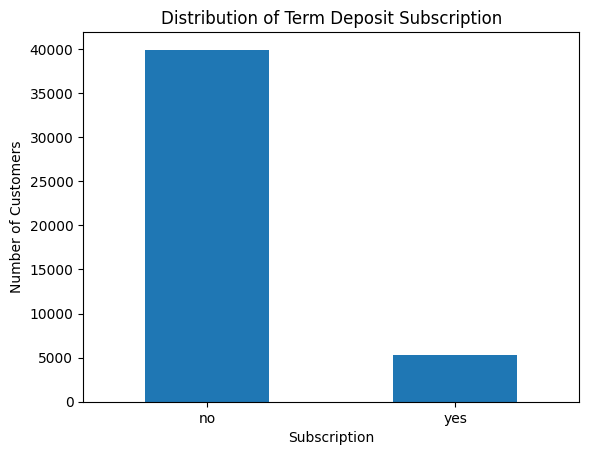

In [49]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar')

plt.title('Distribution of Term Deposit Subscription')
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

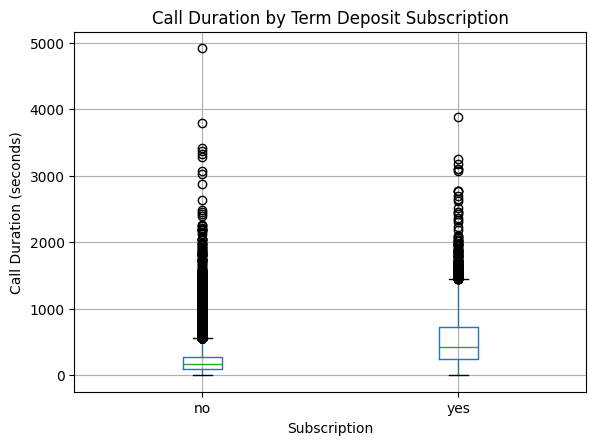

In [51]:
df.boxplot(column='duration', by='y')

plt.title('Call Duration by Term Deposit Subscription')
plt.suptitle('')
plt.xlabel('Subscription')
plt.ylabel('Call Duration (seconds)')
plt.show()

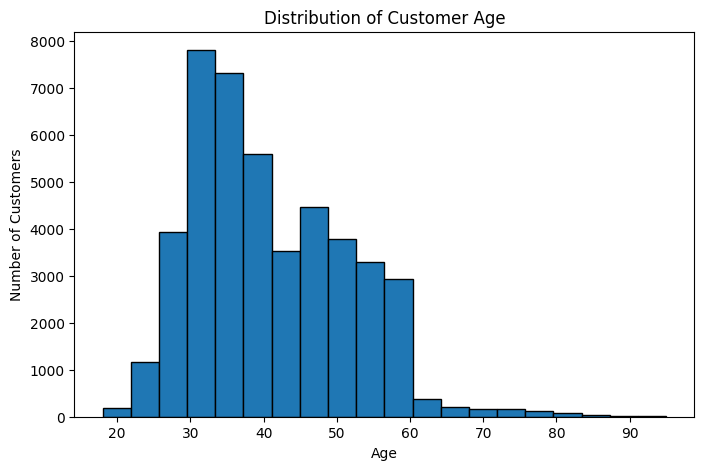

In [53]:
plt.figure(figsize=(8, 5))

plt.hist(df['age'], bins=20, edgecolor='black')

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

In [54]:
job_subscription = pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
) * 100

job_subscription = job_subscription.sort_values('yes', ascending=False)

job_subscription

y,no,yes
job,,
student,71.321962,28.678038
retired,77.208481,22.791519
unemployed,84.497314,15.502686
management,86.244449,13.755551
admin.,87.797331,12.202669
self-employed,88.157061,11.842939
unknown,88.194444,11.805556
technician,88.943004,11.056996
services,91.116996,8.883004


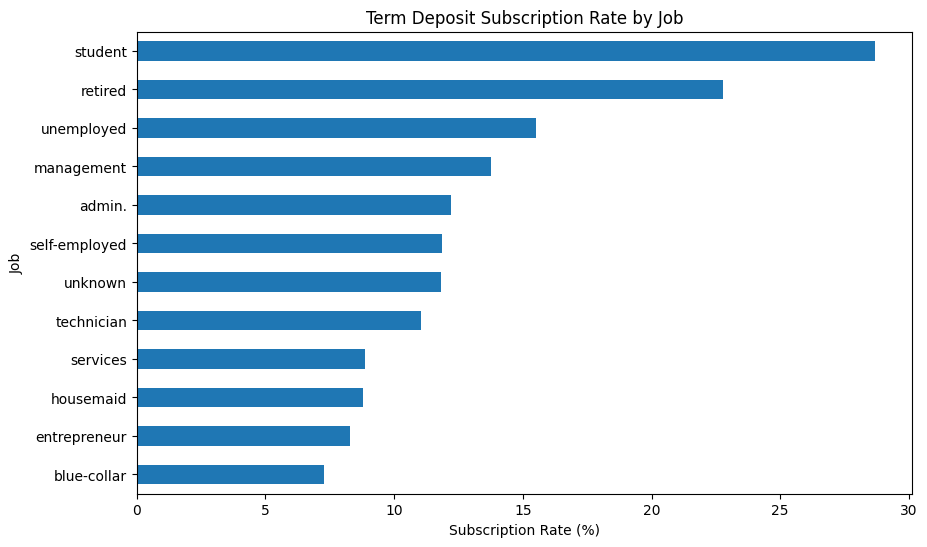

In [55]:
plt.figure(figsize=(10, 6))

job_subscription['yes'].sort_values().plot(kind='barh')

plt.title('Term Deposit Subscription Rate by Job')
plt.xlabel('Subscription Rate (%)')
plt.ylabel('Job')

plt.show()

In [56]:
education_subscription = pd.crosstab(
    df['education'],
    df['y'],
    normalize='index'
) * 100

education_subscription = education_subscription.sort_values('yes', ascending=False)

education_subscription

y,no,yes
education,,
tertiary,84.993610,15.006390
unknown,86.429725,13.570275
secondary,89.440565,10.559435
primary,91.373522,8.626478


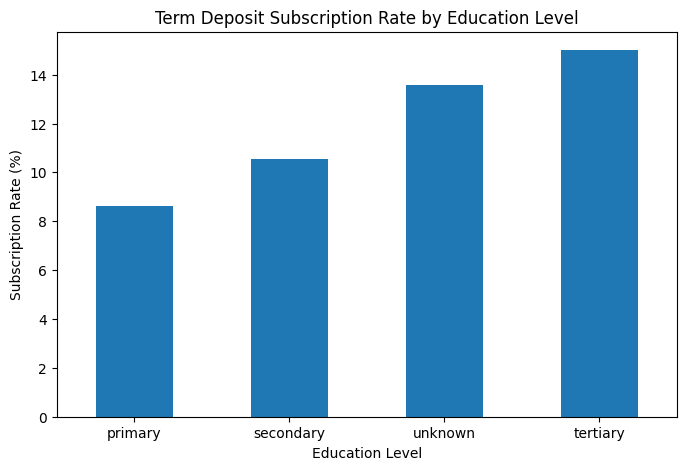

In [57]:
plt.figure(figsize=(8, 5))

education_subscription['yes'].sort_values().plot(kind='bar')

plt.title('Term Deposit Subscription Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [58]:
marital_subscription = pd.crosstab(
    df['marital'],
    df['y'],
    normalize='index'
) * 100

marital_subscription = marital_subscription.sort_values('yes', ascending=False)

marital_subscription

y,no,yes
marital,,
single,85.050821,14.949179
divorced,88.054542,11.945458
married,89.876534,10.123466


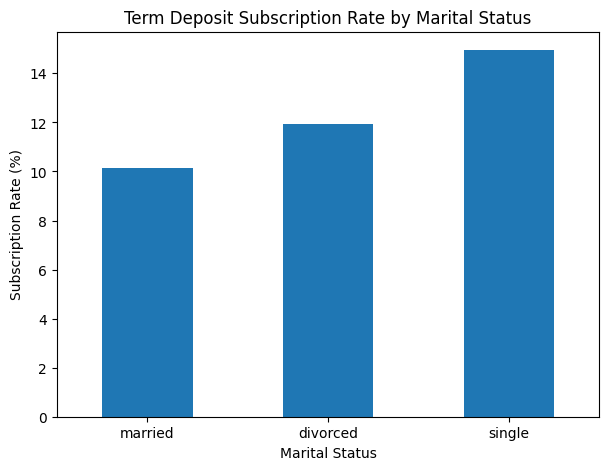

In [59]:
plt.figure(figsize=(7, 5))

marital_subscription['yes'].sort_values().plot(kind='bar')

plt.title('Term Deposit Subscription Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [60]:
housing_subscription = pd.crosstab(
    df['housing'],
    df['y'],
    normalize='index'
) * 100

housing_subscription

y,no,yes
housing,,
no,83.297645,16.702355
yes,92.300040,7.699960


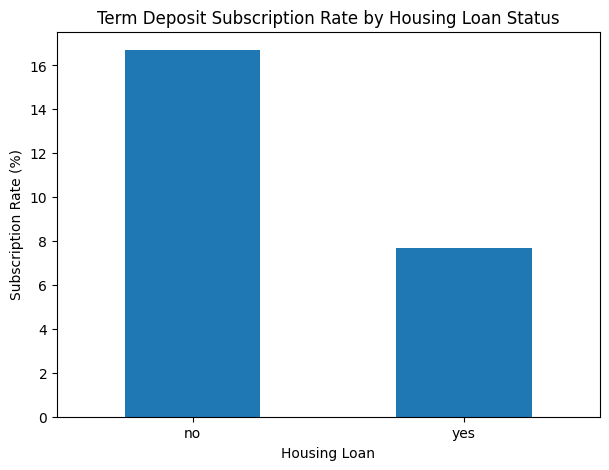

In [61]:
plt.figure(figsize=(7, 5))

housing_subscription['yes'].plot(kind='bar')

plt.title('Term Deposit Subscription Rate by Housing Loan Status')
plt.xlabel('Housing Loan')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [63]:
loan_subscription = pd.crosstab(
    df['loan'],
    df['y'],
    normalize='index'
) * 100

loan_subscription

y,no,yes
loan,,
no,87.344273,12.655727
yes,93.318609,6.681391


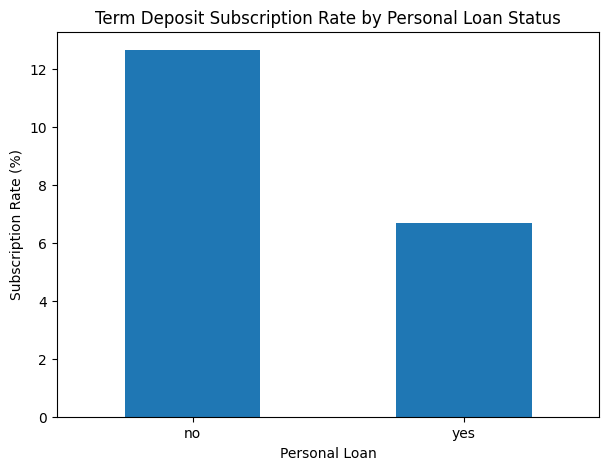

In [64]:
plt.figure(figsize=(7, 5))

loan_subscription['yes'].plot(kind='bar')

plt.title('Term Deposit Subscription Rate by Personal Loan Status')
plt.xlabel('Personal Loan')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [65]:
contact_subscription = pd.crosstab(
    df['contact'],
    df['y'],
    normalize='index'
) * 100

contact_subscription = contact_subscription.sort_values('yes', ascending=False)

contact_subscription

y,no,yes
contact,,
cellular,85.081100,14.918900
telephone,86.579491,13.420509
unknown,95.929339,4.070661


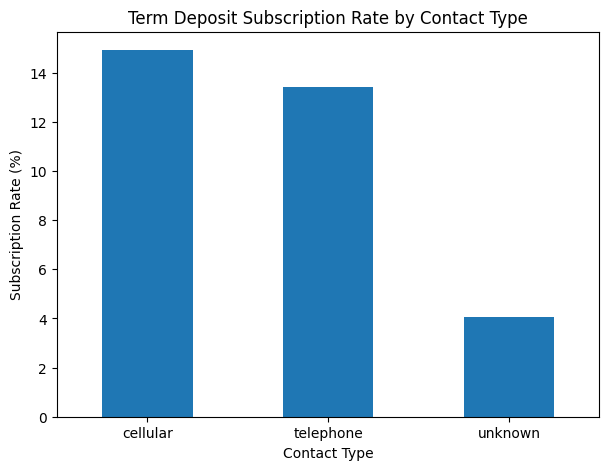

In [66]:
plt.figure(figsize=(7, 5))

contact_subscription['yes'].plot(kind='bar')

plt.title('Term Deposit Subscription Rate by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [67]:
month_subscription = pd.crosstab(
    df['month'],
    df['y'],
    normalize='index'
) * 100

month_subscription

y,no,yes
month,,
apr,80.320600,19.679400
aug,88.986714,11.013286
dec,53.271028,46.728972
feb,83.352208,16.647792
jan,89.878831,10.121169
jul,90.906454,9.093546
jun,89.777195,10.222805
mar,48.008386,51.991614
may,93.280546,6.719454


In [68]:
month_order = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
]

month_subscription = month_subscription.reindex(month_order)

month_subscription

y,no,yes
month,,
jan,89.878831,10.121169
feb,83.352208,16.647792
mar,48.008386,51.991614
apr,80.320600,19.679400
may,93.280546,6.719454
jun,89.777195,10.222805
jul,90.906454,9.093546
aug,88.986714,11.013286
sep,53.540587,46.459413


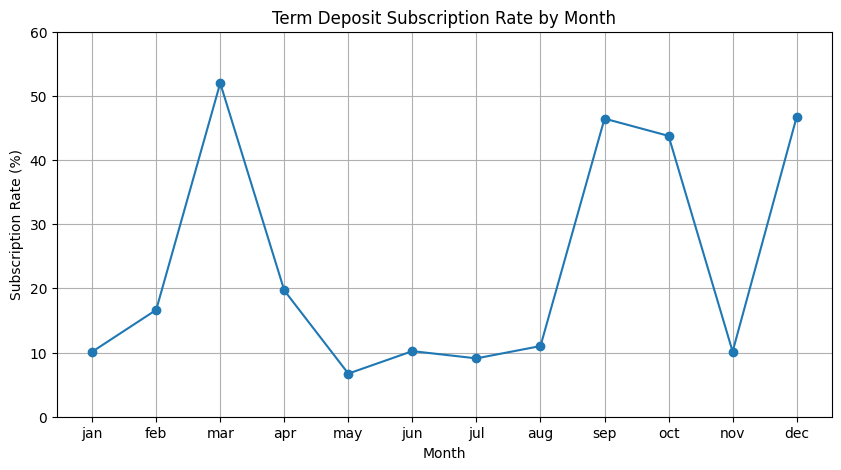

In [69]:
plt.figure(figsize=(10, 5))

plt.plot(
    month_subscription.index,
    month_subscription['yes'],
    marker='o'
)

plt.title('Term Deposit Subscription Rate by Month')
plt.xlabel('Month')
plt.ylabel('Subscription Rate (%)')
plt.ylim(0, 60)

plt.grid(True)
plt.show()

In [70]:
campaign_subscription = pd.crosstab(
    df['campaign'],
    df['y'],
    normalize='index'
) * 100

campaign_subscription[['yes']].head(15)

y,yes
campaign,
1,14.597583
2,11.203519
3,11.193624
4,9.000568
5,7.879819
6,7.126259
7,6.394558
8,5.925926
9,6.422018


In [71]:
campaign_counts = df['campaign'].value_counts().sort_index()

campaign_counts.head(15)

,count
campaign,
1,17544
2,12505
3,5521
4,3522
5,1764
6,1291
7,735
8,540
9,327


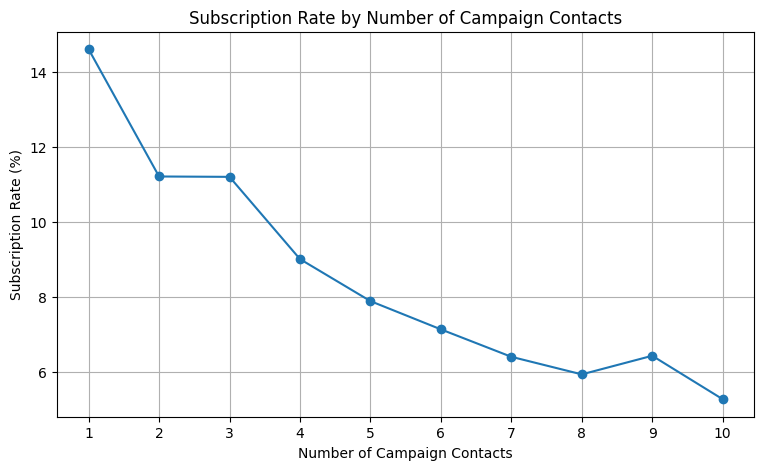

In [72]:
campaign_rate = campaign_subscription.loc[1:10, 'yes']

plt.figure(figsize=(9, 5))

plt.plot(
    campaign_rate.index,
    campaign_rate.values,
    marker='o'
)

plt.title('Subscription Rate by Number of Campaign Contacts')
plt.xlabel('Number of Campaign Contacts')
plt.ylabel('Subscription Rate (%)')

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [73]:
poutcome_subscription = pd.crosstab(
    df['poutcome'],
    df['y'],
    normalize='index'
) * 100

poutcome_subscription = poutcome_subscription.sort_values('yes', ascending=False)

poutcome_subscription

y,no,yes
poutcome,,
success,35.274653,64.725347
other,83.315217,16.684783
failure,87.390329,12.609671
unknown,90.838497,9.161503


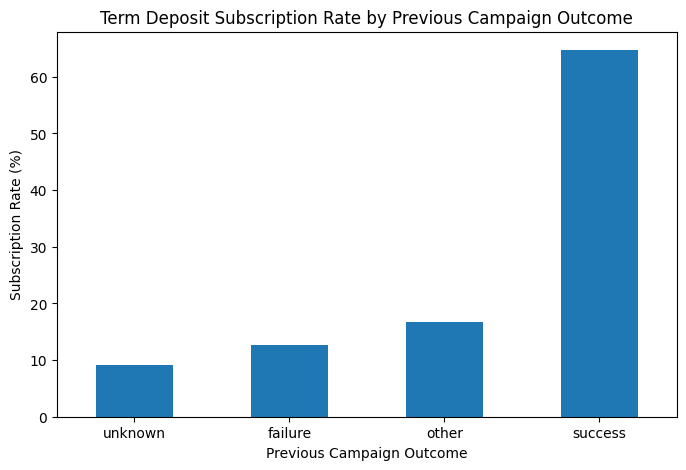

In [74]:
plt.figure(figsize=(8, 5))

poutcome_subscription['yes'].sort_values().plot(kind='bar')

plt.title('Term Deposit Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [75]:
balance_summary = df.groupby('y')['balance'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

balance_summary

,count,mean,median,min,max
y,,,,,
no,39922,1303.714969,417.0,-8019,102127
yes,5289,1804.267915,733.0,-3058,81204


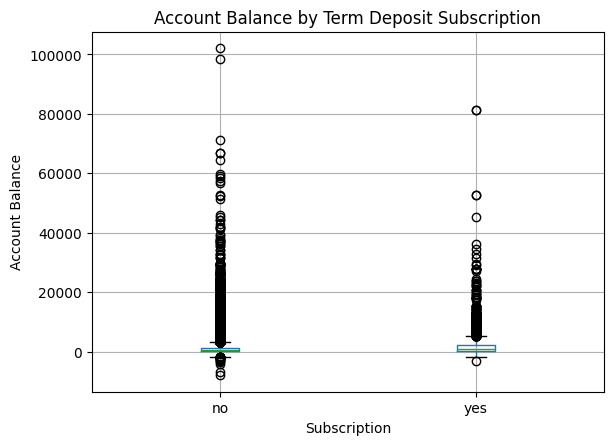

In [76]:
df.boxplot(column='balance', by='y')

plt.title('Account Balance by Term Deposit Subscription')
plt.suptitle('')
plt.xlabel('Subscription')
plt.ylabel('Account Balance')

plt.show()

In [77]:
age_summary = df.groupby('y')['age'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

age_summary

,count,mean,median,min,max
y,,,,,
no,39922,40.838986,39.0,18,95
yes,5289,41.670070,38.0,18,95


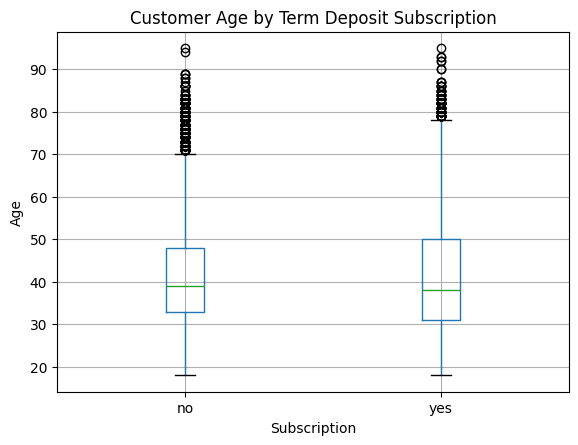

In [78]:
df.boxplot(column='age', by='y')

plt.title('Customer Age by Term Deposit Subscription')
plt.suptitle('')
plt.xlabel('Subscription')
plt.ylabel('Age')

plt.show()

In [79]:
pdays_status = pd.Series({
    'Not previously contacted (-1)': (df['pdays'] == -1).sum(),
    'Previously contacted': (df['pdays'] != -1).sum()
})

pdays_status

,0
Not previously contacted (-1),36954
Previously contacted,8257


In [80]:
df['previous_contact_status'] = df['pdays'].apply(
    lambda x: 'Previously contacted' if x != -1 else 'Not previously contacted'
)

previous_contact_subscription = pd.crosstab(
    df['previous_contact_status'],
    df['y'],
    normalize='index'
) * 100

previous_contact_subscription

y,no,yes
previous_contact_status,,
Not previously contacted,90.842669,9.157331
Previously contacted,76.928667,23.071333


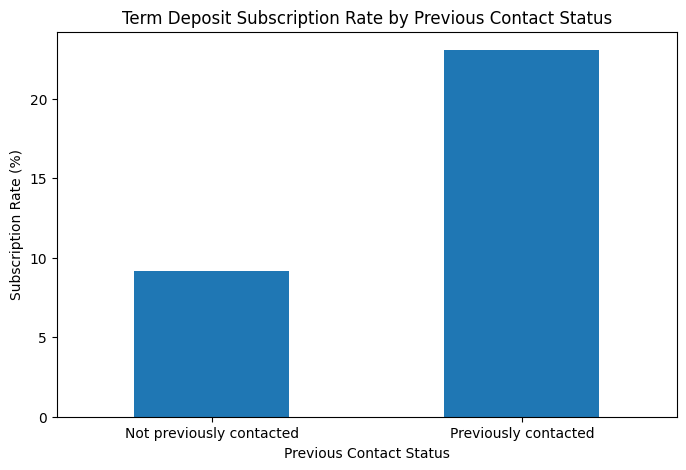

In [81]:
plt.figure(figsize=(8, 5))

previous_contact_subscription['yes'].plot(kind='bar')

plt.title('Term Deposit Subscription Rate by Previous Contact Status')
plt.xlabel('Previous Contact Status')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [82]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

 marital
['married' 'single' 'divorced']

 education
['tertiary' 'secondary' 'unknown' 'primary']

 default
['no' 'yes']

 housing
['yes' 'no']

 loan
['no' 'yes']

 contact
['unknown' 'cellular' 'telephone']

 month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

 poutcome
['unknown' 'failure' 'other' 'success']

 y
['no' 'yes']

 previous_contact_status
['Not previously contacted' 'Previously contacted']


In [83]:
numerical_columns = df.select_dtypes(include='number').columns

outlier_summary = {}

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    outlier_summary[column] = outliers

outlier_summary = pd.Series(outlier_summary).sort_values(ascending=False)

outlier_summary

,0
previous,8257
pdays,8257
balance,4729
duration,3235
campaign,3064
age,487
day,0


In [84]:
skewness = df[numerical_columns].skew().sort_values(ascending=False)

skewness

,0
previous,41.846454
balance,8.360308
campaign,4.898650
duration,3.144318
pdays,2.615715
age,0.684818
day,0.093079


In [85]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix.round(2)

,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.00,0.00,-0.02,0.00
balance,0.10,1.00,0.00,0.02,-0.01,0.00,0.02
day,-0.01,0.00,1.00,-0.03,0.16,-0.09,-0.05
duration,-0.00,0.02,-0.03,1.00,-0.08,-0.00,0.00
campaign,0.00,-0.01,0.16,-0.08,1.00,-0.09,-0.03
pdays,-0.02,0.00,-0.09,-0.00,-0.09,1.00,0.45
previous,0.00,0.02,-0.05,0.00,-0.03,0.45,1.00


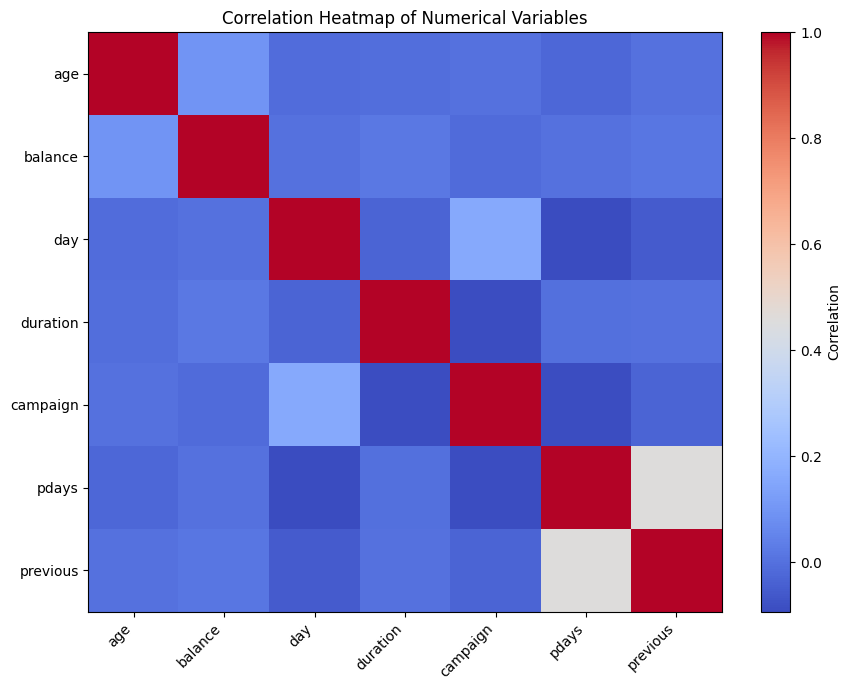

In [86]:
plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.tight_layout()
plt.show()

In [87]:
df_model = df.drop(columns=['previous_contact_status']).copy()

print("Original dataset shape:", df.shape)
print("ML dataset shape:", df_model.shape)
print("\nColumns used for ML:")
print(df_model.columns.tolist())

Original dataset shape: (45211, 18)
ML dataset shape: (45211, 17)

Columns used for ML:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [88]:
X = df_model.drop(columns=['y'])
y = df_model['y'].map({'no': 0, 'yes': 1})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (45211, 16)
y shape: (45211,)

Target values:
y
0    39922
1     5289
Name: count, dtype: int64


In [89]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Number of numerical features: 7
Number of categorical features: 9


In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training features: (36168, 16)
Testing features: (9043, 16)
Training target: (36168,)
Testing target: (9043,)

Training target distribution:
y
0    88.301814
1    11.698186
Name: proportion, dtype: float64

Testing target distribution:
y
0    88.300343
1    11.699657
Name: proportion, dtype: float64


In [91]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [92]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (36168, 51)
Processed testing data shape: (9043, 51)


In [95]:
import numpy as np

print("Training data type:", type(X_train_processed))
print("Testing data type:", type(X_test_processed))

print("\nTraining missing values:", np.isnan(X_train_processed).sum())
print("Testing missing values:", np.isnan(X_test_processed).sum())

print("\nProcessed feature count:", X_train_processed.shape[1])

Training data type: <class 'numpy.ndarray'>
Testing data type: <class 'numpy.ndarray'>

Training missing values: 0
Testing missing values: 0

Processed feature count: 51


In [96]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [97]:
y_pred_logistic = logistic_model.predict(X_test_processed)
y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_logistic))

Predictions generated successfully.
Number of predictions: 9043


In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1-Score :", f1_logistic)
print("ROC-AUC  :", roc_auc_logistic)

Logistic Regression Results
---------------------------
Accuracy : 0.901249585314608
Precision: 0.6444833625218914
Recall   : 0.34782608695652173
F1-Score : 0.4518109269490485
ROC-AUC  : 0.9055740146044154


In [99]:
results = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Accuracy': [accuracy_logistic],
    'Precision': [precision_logistic],
    'Recall': [recall_logistic],
    'F1-Score': [f1_logistic],
    'ROC-AUC': [roc_auc_logistic]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.90125,0.644483,0.347826,0.451811,0.905574


In [100]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

decision_tree_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [101]:
y_pred_tree = decision_tree_model.predict(X_test_processed)
y_prob_tree = decision_tree_model.predict_proba(X_test_processed)[:, 1]

print("Decision Tree predictions generated successfully.")
print("Number of predictions:", len(y_pred_tree))

Decision Tree predictions generated successfully.
Number of predictions: 9043


In [102]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_tree)
print("Precision:", precision_tree)
print("Recall   :", recall_tree)
print("F1-Score :", f1_tree)
print("ROC-AUC  :", roc_auc_tree)

Decision Tree Results
---------------------
Accuracy : 0.8782483689041247
Precision: 0.47847847847847846
Recall   : 0.45179584120982985
F1-Score : 0.4647544968400583
ROC-AUC  : 0.6932742512248273


In [103]:
results.loc[len(results)] = [
    'Decision Tree',
    accuracy_tree,
    precision_tree,
    recall_tree,
    f1_tree,
    roc_auc_tree
]

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.901250,0.644483,0.347826,0.451811,0.905574
1,Decision Tree,0.878248,0.478478,0.451796,0.464754,0.693274


In [104]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [105]:
y_pred_rf = random_forest_model.predict(X_test_processed)
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions generated successfully.
Number of predictions: 9043


In [106]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

Random Forest Results
---------------------
Accuracy : 0.9051199823067566
Precision: 0.6937984496124031
Recall   : 0.3383742911153119
F1-Score : 0.4548919949174079
ROC-AUC  : 0.928626630982241


In [107]:
results.loc[len(results)] = [
    'Random Forest',
    accuracy_rf,
    precision_rf,
    recall_rf,
    f1_rf,
    roc_auc_rf
]

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.901250,0.644483,0.347826,0.451811,0.905574
1,Decision Tree,0.878248,0.478478,0.451796,0.464754,0.693274
2,Random Forest,0.905120,0.693798,0.338374,0.454892,0.928627


In [108]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train_processed, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [109]:
y_pred_gb = gradient_boosting_model.predict(X_test_processed)
y_prob_gb = gradient_boosting_model.predict_proba(X_test_processed)[:, 1]

print("Gradient Boosting predictions generated successfully.")
print("Number of predictions:", len(y_pred_gb))

Gradient Boosting predictions generated successfully.
Number of predictions: 9043


In [110]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting Results")
print("-------------------------")
print("Accuracy :", accuracy_gb)
print("Precision:", precision_gb)
print("Recall   :", recall_gb)
print("F1-Score :", f1_gb)
print("ROC-AUC  :", roc_auc_gb)

Gradient Boosting Results
-------------------------
Accuracy : 0.9062258100187991
Precision: 0.657185628742515
Recall   : 0.41493383742911155
F1-Score : 0.5086906141367323
ROC-AUC  : 0.9246486500562846


In [111]:
results.loc[len(results)] = [
    'Gradient Boosting',
    accuracy_gb,
    precision_gb,
    recall_gb,
    f1_gb,
    roc_auc_gb
]

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.901250,0.644483,0.347826,0.451811,0.905574
1,Decision Tree,0.878248,0.478478,0.451796,0.464754,0.693274
2,Random Forest,0.905120,0.693798,0.338374,0.454892,0.928627
3,Gradient Boosting,0.906226,0.657186,0.414934,0.508691,0.924649


In [112]:
results_formatted = results.copy()

metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

results_formatted[metric_columns] = results_formatted[metric_columns].round(4)

results_formatted

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9012,0.6445,0.3478,0.4518,0.9056
1,Decision Tree,0.8782,0.4785,0.4518,0.4648,0.6933
2,Random Forest,0.9051,0.6938,0.3384,0.4549,0.9286
3,Gradient Boosting,0.9062,0.6572,0.4149,0.5087,0.9246


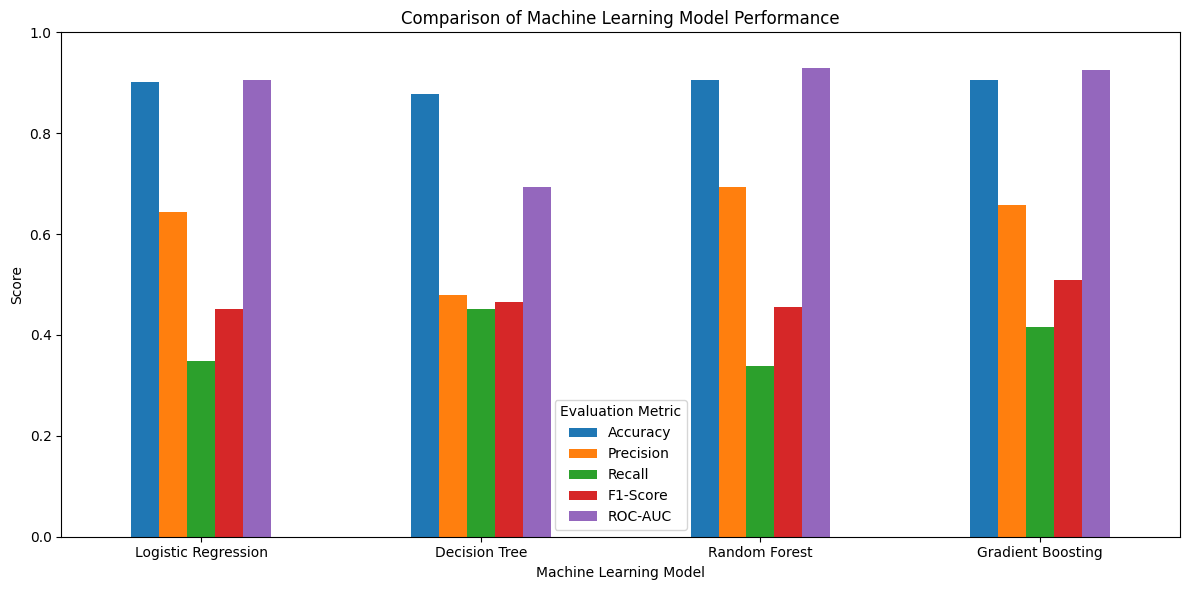

In [113]:
import matplotlib.pyplot as plt

results_plot = results_formatted.set_index('Model')

results_plot[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Comparison of Machine Learning Model Performance')
plt.xlabel('Machine Learning Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Evaluation Metric')
plt.tight_layout()
plt.show()

Gradient Boosting Confusion Matrix:
[[7756  229]
 [ 619  439]]


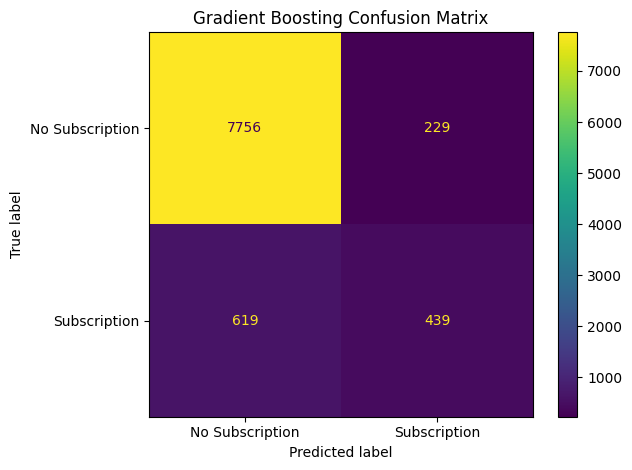

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_gb = confusion_matrix(y_test, y_pred_gb)

print("Gradient Boosting Confusion Matrix:")
print(cm_gb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=['No Subscription', 'Subscription']
)

disp.plot()
plt.title('Gradient Boosting Confusion Matrix')
plt.tight_layout()
plt.show()

In [115]:
from sklearn.metrics import classification_report

print("Gradient Boosting Classification Report")
print("----------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_gb,
        target_names=['No Subscription', 'Subscription']
    )
)

Gradient Boosting Classification Report
----------------------------------------
                 precision    recall  f1-score   support

No Subscription       0.93      0.97      0.95      7985
   Subscription       0.66      0.41      0.51      1058

       accuracy                           0.91      9043
      macro avg       0.79      0.69      0.73      9043
   weighted avg       0.89      0.91      0.90      9043



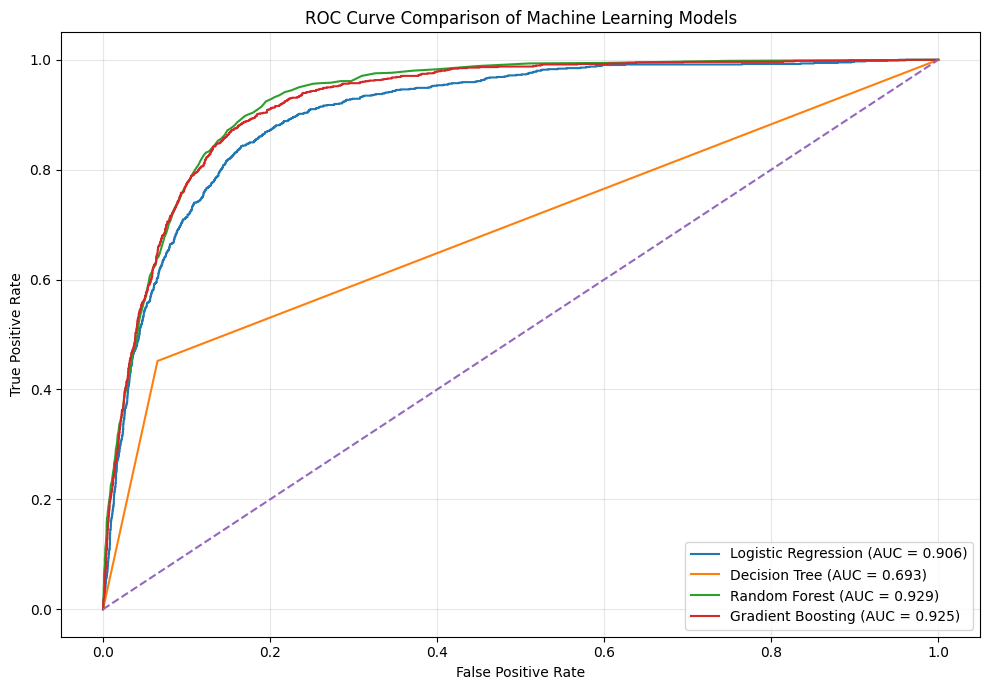

In [116]:
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f'Logistic Regression (AUC = {roc_auc_logistic:.3f})'
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f'Decision Tree (AUC = {roc_auc_tree:.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_rf:.3f})'
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f'Gradient Boosting (AUC = {roc_auc_gb:.3f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Machine Learning Models')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [117]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print("Top 15 most important features:")
print(feature_importance.head(15))

Top 15 most important features:
                  Feature  Importance
3           num__duration    0.345097
1            num__balance    0.074645
0                num__age    0.070328
2                num__day    0.065549
4           num__campaign    0.033388
49  cat__poutcome_success    0.032357
5              num__pdays    0.031018
34   cat__contact_unknown    0.026040
6           num__previous    0.018872
28        cat__housing_no    0.017693
29       cat__housing_yes    0.016602
32  cat__contact_cellular    0.015629
35         cat__month_apr    0.012251
43         cat__month_may    0.011990
36         cat__month_aug    0.011832


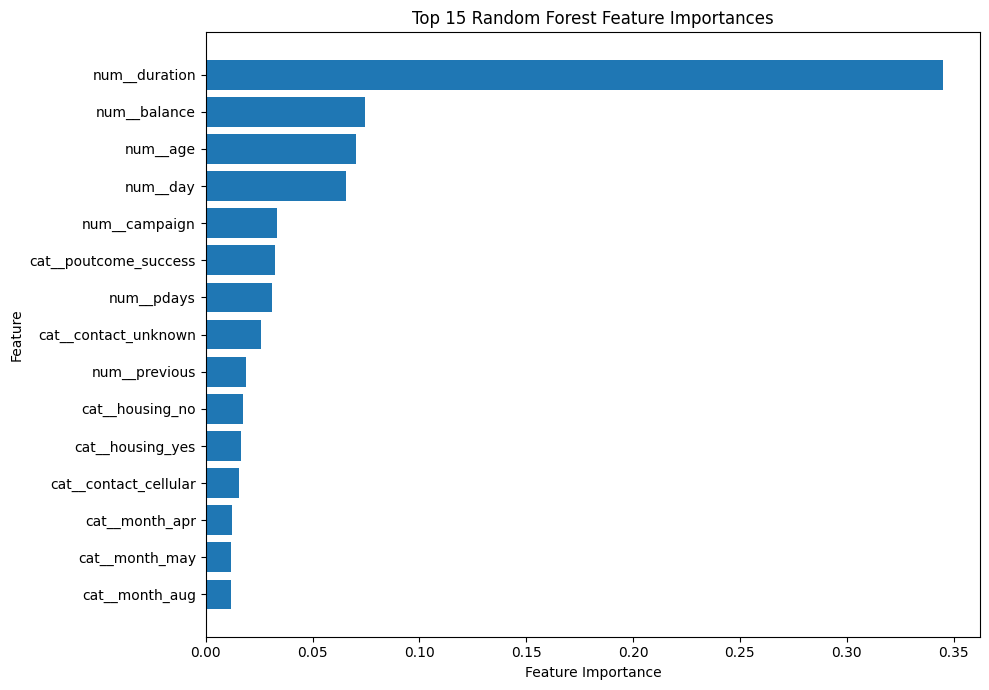

In [118]:
top_features = feature_importance.head(15).sort_values(
    'Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Random Forest Feature Importances')

plt.tight_layout()
plt.show()

In [119]:
X_train_realistic = X_train.drop(columns=['duration'])
X_test_realistic = X_test.drop(columns=['duration'])

print("Original training shape:", X_train.shape)
print("Realistic training shape:", X_train_realistic.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Realistic testing shape:", X_test_realistic.shape)

print("\nDuration removed successfully:")
print('duration' in X_train_realistic.columns)

Original training shape: (36168, 16)
Realistic training shape: (36168, 15)

Original testing shape: (9043, 16)
Realistic testing shape: (9043, 15)

Duration removed successfully:
False


In [120]:
numerical_features_realistic = X_train_realistic.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features_realistic = X_train_realistic.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numerical_features_realistic)

print("\nCategorical features:")
print(categorical_features_realistic)

print("\nNumber of numerical features:", len(numerical_features_realistic))
print("Number of categorical features:", len(categorical_features_realistic))

Numerical features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Number of numerical features: 6
Number of categorical features: 9


In [121]:
preprocessor_realistic = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_realistic),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_realistic)
    ]
)

print("Realistic preprocessing pipeline created successfully.")

Realistic preprocessing pipeline created successfully.


In [122]:
X_train_realistic_processed = preprocessor_realistic.fit_transform(
    X_train_realistic
)

X_test_realistic_processed = preprocessor_realistic.transform(
    X_test_realistic
)

print("Realistic processed training shape:",
      X_train_realistic_processed.shape)

print("Realistic processed testing shape:",
      X_test_realistic_processed.shape)

Realistic processed training shape: (36168, 50)
Realistic processed testing shape: (9043, 50)


In [123]:
print("Training missing values:",
      np.isnan(X_train_realistic_processed).sum())

print("Testing missing values:",
      np.isnan(X_test_realistic_processed).sum())

print("\nProcessed feature count:",
      X_train_realistic_processed.shape[1])

Training missing values: 0
Testing missing values: 0

Processed feature count: 50


In [124]:
logistic_realistic = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_realistic.fit(
    X_train_realistic_processed,
    y_train
)

print("Realistic Logistic Regression model trained successfully.")

Realistic Logistic Regression model trained successfully.


In [125]:
y_pred_lr_realistic = logistic_realistic.predict(
    X_test_realistic_processed
)

y_prob_lr_realistic = logistic_realistic.predict_proba(
    X_test_realistic_processed
)[:, 1]

print("Realistic Logistic Regression predictions generated successfully.")
print("Number of predictions:", len(y_pred_lr_realistic))

Realistic Logistic Regression predictions generated successfully.
Number of predictions: 9043


In [126]:
accuracy_lr_realistic = accuracy_score(
    y_test, y_pred_lr_realistic
)

precision_lr_realistic = precision_score(
    y_test, y_pred_lr_realistic
)

recall_lr_realistic = recall_score(
    y_test, y_pred_lr_realistic
)

f1_lr_realistic = f1_score(
    y_test, y_pred_lr_realistic
)

roc_auc_lr_realistic = roc_auc_score(
    y_test, y_prob_lr_realistic
)

print("Realistic Logistic Regression Results")
print("-------------------------------------")
print("Accuracy :", accuracy_lr_realistic)
print("Precision:", precision_lr_realistic)
print("Recall   :", recall_lr_realistic)
print("F1-Score :", f1_lr_realistic)
print("ROC-AUC  :", roc_auc_lr_realistic)

Realistic Logistic Regression Results
-------------------------------------
Accuracy : 0.8932876257879022
Precision: 0.6631578947368421
Recall   : 0.1786389413988658
F1-Score : 0.28145941921072226
ROC-AUC  : 0.7717487775401183


In [127]:
realistic_results = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Accuracy': [accuracy_lr_realistic],
    'Precision': [precision_lr_realistic],
    'Recall': [recall_lr_realistic],
    'F1-Score': [f1_lr_realistic],
    'ROC-AUC': [roc_auc_lr_realistic]
})

realistic_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.893288,0.663158,0.178639,0.281459,0.771749


In [128]:
decision_tree_realistic = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

decision_tree_realistic.fit(
    X_train_realistic_processed,
    y_train
)

print("Realistic Decision Tree model trained successfully.")

Realistic Decision Tree model trained successfully.


In [129]:
y_pred_dt_realistic = decision_tree_realistic.predict(
    X_test_realistic_processed
)

y_prob_dt_realistic = decision_tree_realistic.predict_proba(
    X_test_realistic_processed
)[:, 1]

print("Realistic Decision Tree predictions generated successfully.")
print("Number of predictions:", len(y_pred_dt_realistic))

Realistic Decision Tree predictions generated successfully.
Number of predictions: 9043


In [130]:
accuracy_dt_realistic = accuracy_score(
    y_test, y_pred_dt_realistic
)

precision_dt_realistic = precision_score(
    y_test, y_pred_dt_realistic
)

recall_dt_realistic = recall_score(
    y_test, y_pred_dt_realistic
)

f1_dt_realistic = f1_score(
    y_test, y_pred_dt_realistic
)

roc_auc_dt_realistic = roc_auc_score(
    y_test, y_prob_dt_realistic
)

print("Realistic Decision Tree Results")
print("--------------------------------")
print("Accuracy :", accuracy_dt_realistic)
print("Precision:", precision_dt_realistic)
print("Recall   :", recall_dt_realistic)
print("F1-Score :", f1_dt_realistic)
print("ROC-AUC  :", roc_auc_dt_realistic)

Realistic Decision Tree Results
--------------------------------
Accuracy : 0.840207895609864
Precision: 0.3059177532597793
Recall   : 0.2882797731568998
F1-Score : 0.29683698296836986
ROC-AUC  : 0.6008086404920379


In [131]:
realistic_results.loc[len(realistic_results)] = [
    'Decision Tree',
    accuracy_dt_realistic,
    precision_dt_realistic,
    recall_dt_realistic,
    f1_dt_realistic,
    roc_auc_dt_realistic
]

realistic_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.893288,0.663158,0.178639,0.281459,0.771749
1,Decision Tree,0.840208,0.305918,0.288280,0.296837,0.600809


In [132]:
random_forest_realistic = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

random_forest_realistic.fit(
    X_train_realistic_processed,
    y_train
)

print("Realistic Random Forest model trained successfully.")

Realistic Random Forest model trained successfully.


In [135]:
from sklearn.ensemble import RandomForestClassifier

random_forest_realistic = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

random_forest_realistic.fit(
    X_train_realistic_processed,
    y_train
)

print("Realistic Random Forest model trained successfully.")

Realistic Random Forest model trained successfully.


In [136]:
y_pred_rf_realistic = random_forest_realistic.predict(
    X_test_realistic_processed
)

y_prob_rf_realistic = random_forest_realistic.predict_proba(
    X_test_realistic_processed
)[:, 1]

print("Realistic Random Forest predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf_realistic))

Realistic Random Forest predictions generated successfully.
Number of predictions: 9043


In [137]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_realistic_accuracy = accuracy_score(y_test, y_pred_rf_realistic)
rf_realistic_precision = precision_score(y_test, y_pred_rf_realistic)
rf_realistic_recall = recall_score(y_test, y_pred_rf_realistic)
rf_realistic_f1 = f1_score(y_test, y_pred_rf_realistic)
rf_realistic_auc = roc_auc_score(y_test, y_prob_rf_realistic)

print("Realistic Random Forest Results")
print("--------------------------------")
print("Accuracy :", rf_realistic_accuracy)
print("Precision:", rf_realistic_precision)
print("Recall   :", rf_realistic_recall)
print("F1-Score :", rf_realistic_f1)
print("ROC-AUC  :", rf_realistic_auc)

Realistic Random Forest Results
--------------------------------
Accuracy : 0.8932876257879022
Precision: 0.6302521008403361
Recall   : 0.21266540642722118
F1-Score : 0.31802120141342755
ROC-AUC  : 0.7929442965484669


In [138]:
realistic_results = pd.concat([
    realistic_results,
    pd.DataFrame({
        'Model': ['Random Forest'],
        'Accuracy': [rf_realistic_accuracy],
        'Precision': [rf_realistic_precision],
        'Recall': [rf_realistic_recall],
        'F1-Score': [rf_realistic_f1],
        'ROC-AUC': [rf_realistic_auc]
    })
], ignore_index=True)

realistic_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.893288,0.663158,0.178639,0.281459,0.771749
1,Decision Tree,0.840208,0.305918,0.288280,0.296837,0.600809
2,Random Forest,0.893288,0.630252,0.212665,0.318021,0.792944


In [139]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_realistic = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_realistic.fit(
    X_train_realistic_processed,
    y_train
)

print("Realistic Gradient Boosting model trained successfully.")

Realistic Gradient Boosting model trained successfully.


In [140]:
y_pred_gb_realistic = gradient_boosting_realistic.predict(
    X_test_realistic_processed
)

y_prob_gb_realistic = gradient_boosting_realistic.predict_proba(
    X_test_realistic_processed
)[:, 1]

print("Realistic Gradient Boosting predictions generated successfully.")
print("Number of predictions:", len(y_pred_gb_realistic))

Realistic Gradient Boosting predictions generated successfully.
Number of predictions: 9043


In [141]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

gb_realistic_accuracy = accuracy_score(
    y_test, y_pred_gb_realistic
)

gb_realistic_precision = precision_score(
    y_test, y_pred_gb_realistic
)

gb_realistic_recall = recall_score(
    y_test, y_pred_gb_realistic
)

gb_realistic_f1 = f1_score(
    y_test, y_pred_gb_realistic
)

gb_realistic_auc = roc_auc_score(
    y_test, y_prob_gb_realistic
)

print("Realistic Gradient Boosting Results")
print("-----------------------------------")
print("Accuracy :", gb_realistic_accuracy)
print("Precision:", gb_realistic_precision)
print("Recall   :", gb_realistic_recall)
print("F1-Score :", gb_realistic_f1)
print("ROC-AUC  :", gb_realistic_auc)

Realistic Gradient Boosting Results
-----------------------------------
Accuracy : 0.8948357845847617
Precision: 0.6666666666666666
Recall   : 0.20226843100189035
F1-Score : 0.3103698332124728
ROC-AUC  : 0.8019277638956788


In [142]:
realistic_results = pd.concat([
    realistic_results,
    pd.DataFrame({
        'Model': ['Gradient Boosting'],
        'Accuracy': [gb_realistic_accuracy],
        'Precision': [gb_realistic_precision],
        'Recall': [gb_realistic_recall],
        'F1-Score': [gb_realistic_f1],
        'ROC-AUC': [gb_realistic_auc]
    })
], ignore_index=True)

realistic_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.893288,0.663158,0.178639,0.281459,0.771749
1,Decision Tree,0.840208,0.305918,0.288280,0.296837,0.600809
2,Random Forest,0.893288,0.630252,0.212665,0.318021,0.792944
3,Gradient Boosting,0.894836,0.666667,0.202268,0.310370,0.801928


In [143]:
realistic_results_rounded = realistic_results.copy()

metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

realistic_results_rounded[metric_columns] = (
    realistic_results_rounded[metric_columns].round(4)
)

realistic_results_rounded

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8933,0.6632,0.1786,0.2815,0.7717
1,Decision Tree,0.8402,0.3059,0.2883,0.2968,0.6008
2,Random Forest,0.8933,0.6303,0.2127,0.3180,0.7929
3,Gradient Boosting,0.8948,0.6667,0.2023,0.3104,0.8019


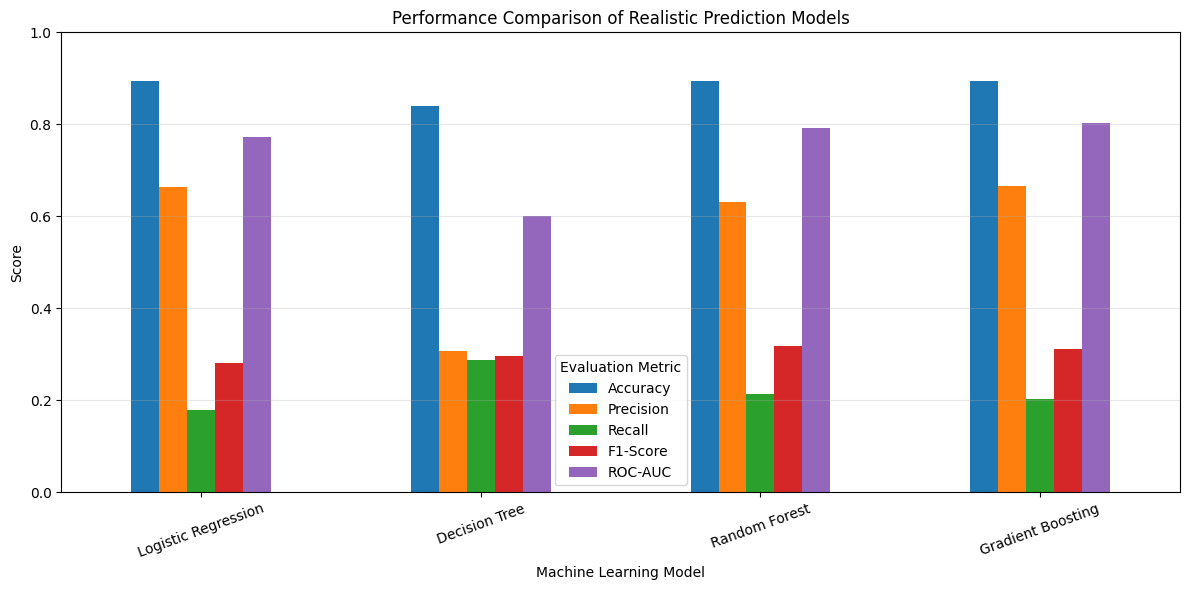

In [144]:
import matplotlib.pyplot as plt

realistic_results_plot = realistic_results.set_index('Model')

realistic_results_plot[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Performance Comparison of Realistic Prediction Models')
plt.xlabel('Machine Learning Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title='Evaluation Metric')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Confusion Matrix:
[[7878  107]
 [ 844  214]]


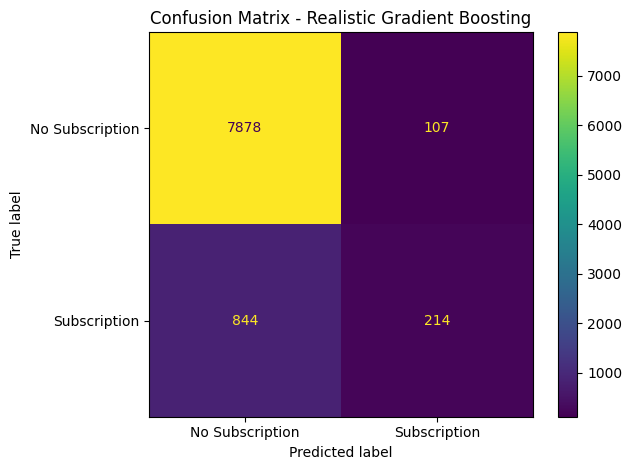

In [145]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_gb_realistic = confusion_matrix(
    y_test,
    y_pred_gb_realistic
)

print("Confusion Matrix:")
print(cm_gb_realistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb_realistic,
    display_labels=['No Subscription', 'Subscription']
)

disp.plot()
plt.title('Confusion Matrix - Realistic Gradient Boosting')
plt.tight_layout()
plt.show()

In [146]:
from sklearn.metrics import classification_report

print("Classification Report - Realistic Gradient Boosting")
print("---------------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_gb_realistic,
        target_names=['No Subscription', 'Subscription']
    )
)

Classification Report - Realistic Gradient Boosting
---------------------------------------------------
                 precision    recall  f1-score   support

No Subscription       0.90      0.99      0.94      7985
   Subscription       0.67      0.20      0.31      1058

       accuracy                           0.89      9043
      macro avg       0.78      0.59      0.63      9043
   weighted avg       0.88      0.89      0.87      9043



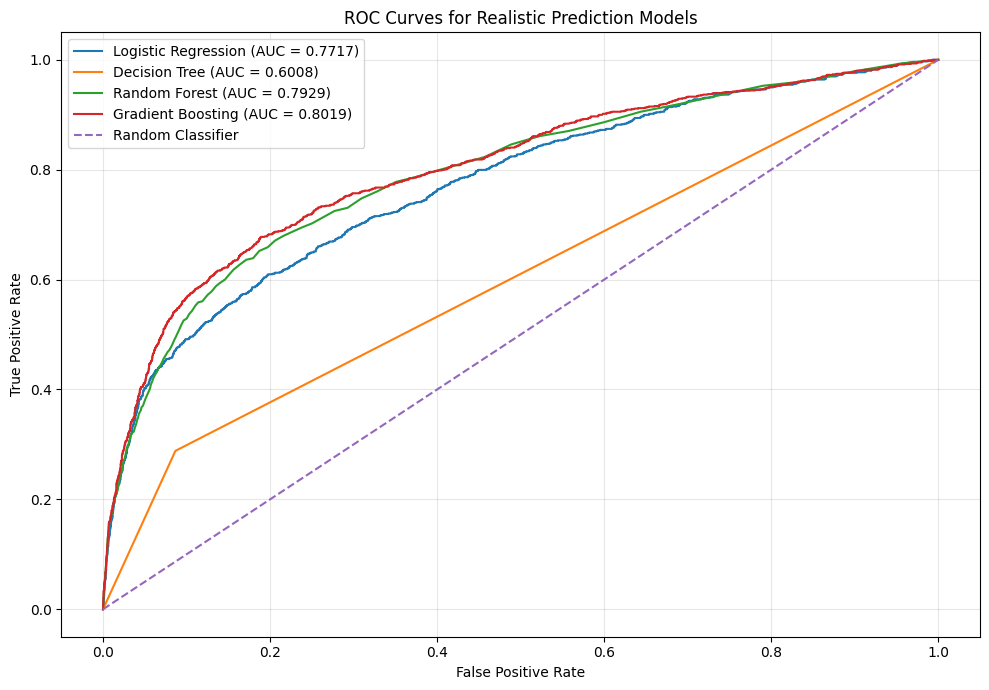

In [151]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Generate probabilities for Logistic Regression
y_prob_lr_realistic = logistic_realistic.predict_proba(
    X_test_realistic_processed
)[:, 1]

# Generate probabilities for Decision Tree
y_prob_dt_realistic = decision_tree_realistic.predict_proba(
    X_test_realistic_processed
)[:, 1]

# Random Forest and Gradient Boosting probabilities already exist
# y_prob_rf_realistic
# y_prob_gb_realistic

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(
    y_test, y_prob_lr_realistic
)

fpr_dt, tpr_dt, _ = roc_curve(
    y_test, y_prob_dt_realistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test, y_prob_rf_realistic
)

fpr_gb, tpr_gb, _ = roc_curve(
    y_test, y_prob_gb_realistic
)

# Calculate AUC values
auc_lr = roc_auc_score(y_test, y_prob_lr_realistic)
auc_dt = roc_auc_score(y_test, y_prob_dt_realistic)
auc_rf = roc_auc_score(y_test, y_prob_rf_realistic)
auc_gb = roc_auc_score(y_test, y_prob_gb_realistic)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(
    fpr_lr, tpr_lr,
    label=f'Logistic Regression (AUC = {auc_lr:.4f})'
)

plt.plot(
    fpr_dt, tpr_dt,
    label=f'Decision Tree (AUC = {auc_dt:.4f})'
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.4f})'
)

plt.plot(
    fpr_gb, tpr_gb,
    label=f'Gradient Boosting (AUC = {auc_gb:.4f})'
)

plt.plot(
    [0, 1], [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Realistic Prediction Models')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [152]:
# Get feature importance values
rf_importances = random_forest_realistic.feature_importances_

# Build feature names in the same order used by the realistic preprocessor
numeric_features_realistic = [
    'age',
    'balance',
    'day',
    'campaign',
    'pdays',
    'previous'
]

categorical_features_realistic = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

feature_names_realistic = numeric_features_realistic.copy()

for column in categorical_features_realistic:
    categories = sorted(X_train_realistic[column].unique())
    feature_names_realistic.extend(
        [f'{column}_{category}' for category in categories]
    )

# Create feature importance table
rf_feature_importance = pd.DataFrame({
    'Feature': feature_names_realistic,
    'Importance': rf_importances
})

# Sort from highest to lowest
rf_feature_importance = rf_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

rf_feature_importance.head(15)

,Feature,Importance
1,balance,0.159553
0,age,0.135586
2,day,0.120480
3,campaign,0.067569
4,pdays,0.040700
48,poutcome_success,0.033849
33,contact_unknown,0.026003
5,previous,0.022008
27,housing_no,0.018906
31,contact_cellular,0.018528


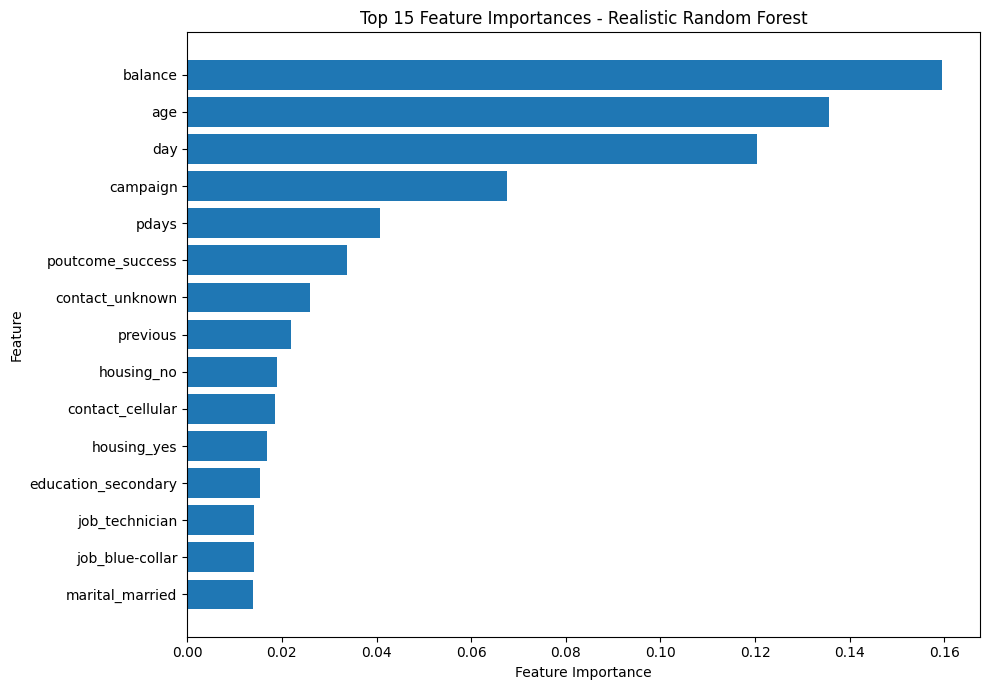

In [153]:
top_features = rf_feature_importance.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Realistic Random Forest')
plt.tight_layout()
plt.show()

In [154]:
final_model_results = realistic_results.copy()

final_model_results = final_model_results[
    [
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC'
    ]
]

final_model_results = final_model_results.round(4)

final_model_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8933,0.6632,0.1786,0.2815,0.7717
1,Decision Tree,0.8402,0.3059,0.2883,0.2968,0.6008
2,Random Forest,0.8933,0.6303,0.2127,0.3180,0.7929
3,Gradient Boosting,0.8948,0.6667,0.2023,0.3104,0.8019


In [155]:
!pip install -q pyspark

In [156]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BankMarketingAnalysis") \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark session created successfully.")

Spark version: 4.0.4
Spark session created successfully.


In [157]:
spark_df = spark.read.csv(
    "/content/bank-full.csv",
    header=True,
    inferSchema=True,
    sep=";"
)

print("Spark DataFrame created successfully.")
print("Number of rows:", spark_df.count())
print("Number of columns:", len(spark_df.columns))

Spark DataFrame created successfully.
Number of rows: 45211
Number of columns: 17


In [158]:
spark_df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [159]:
spark_target_counts = spark_df.groupBy("y").count()

spark_target_counts.show()

+---+-----+
|  y|count|
+---+-----+
| no|39922|
|yes| 5289|
+---+-----+



In [160]:
spark_job_analysis = spark_df.groupBy("job", "y").count() \
    .orderBy("job", "y")

spark_job_analysis.show(50, truncate=False)

+-------------+---+-----+
|job          |y  |count|
+-------------+---+-----+
|admin.       |no |4540 |
|admin.       |yes|631  |
|blue-collar  |no |9024 |
|blue-collar  |yes|708  |
|entrepreneur |no |1364 |
|entrepreneur |yes|123  |
|housemaid    |no |1131 |
|housemaid    |yes|109  |
|management   |no |8157 |
|management   |yes|1301 |
|retired      |no |1748 |
|retired      |yes|516  |
|self-employed|no |1392 |
|self-employed|yes|187  |
|services     |no |3785 |
|services     |yes|369  |
|student      |no |669  |
|student      |yes|269  |
|technician   |no |6757 |
|technician   |yes|840  |
|unemployed   |no |1101 |
|unemployed   |yes|202  |
|unknown      |no |254  |
|unknown      |yes|34   |
+-------------+---+-----+



In [161]:
from pyspark.sql.functions import sum, when, count, round

spark_job_rate = spark_df.groupBy("job").agg(
    count("*").alias("total_customers"),
    sum(when(spark_df["y"] == "yes", 1).otherwise(0)).alias("subscribed")
)

spark_job_rate = spark_job_rate.withColumn(
    "subscription_rate",
    round(
        (spark_job_rate["subscribed"] / spark_job_rate["total_customers"]) * 100,
        2
    )
)

spark_job_rate.orderBy(
    "subscription_rate",
    ascending=False
).show(20, truncate=False)

+-------------+---------------+----------+-----------------+
|job          |total_customers|subscribed|subscription_rate|
+-------------+---------------+----------+-----------------+
|student      |938            |269       |28.68            |
|retired      |2264           |516       |22.79            |
|unemployed   |1303           |202       |15.5             |
|management   |9458           |1301      |13.76            |
|admin.       |5171           |631       |12.2             |
|self-employed|1579           |187       |11.84            |
|unknown      |288            |34        |11.81            |
|technician   |7597           |840       |11.06            |
|services     |4154           |369       |8.88             |
|housemaid    |1240           |109       |8.79             |
|entrepreneur |1487           |123       |8.27             |
|blue-collar  |9732           |708       |7.27             |
+-------------+---------------+----------+-----------------+



In [163]:
import time

start_time = time.time()

spark_job_rate = spark_df.groupBy("job").agg(
    count("*").alias("total_customers"),
    sum(when(spark_df["y"] == "yes", 1).otherwise(0)).alias("subscribed")
)

spark_job_rate = spark_job_rate.withColumn(
    "subscription_rate",
    round(
        (spark_job_rate["subscribed"] / spark_job_rate["total_customers"]) * 100,
        2
    )
)

spark_job_rate.orderBy(
    "subscription_rate",
    ascending=False
).collect()

end_time = time.time()

execution_time = end_time - start_time

print("Spark aggregation completed successfully.")
print("Execution time:", execution_time, "seconds")

Spark aggregation completed successfully.
Execution time: 1.2280383110046387 seconds


In [164]:
spark.stop()

print("Spark session stopped successfully.")

Spark session stopped successfully.


In [165]:
final_evidence = pd.DataFrame({
    'Item': [
        'Dataset rows',
        'Dataset columns',
        'Training rows',
        'Testing rows',
        'Target: No subscription',
        'Target: Subscription',
        'Processed features with duration',
        'Processed features without duration',
        'Spark version',
        'Spark aggregation execution time'
    ],
    'Value': [
        df.shape[0],
        df.shape[1],
        X_train.shape[0],
        X_test.shape[0],
        int((y == 0).sum()),
        int((y == 1).sum()),
        X_train_processed.shape[1],
        X_train_realistic_processed.shape[1],
        '4.0.4',
        '1.2280 seconds'
    ]
})

final_evidence

,Item,Value
0,Dataset rows,45211
1,Dataset columns,18
2,Training rows,36168
3,Testing rows,9043
4,Target: No subscription,39922
5,Target: Subscription,5289
6,Processed features with duration,51
7,Processed features without duration,50
8,Spark version,4.0.4
9,Spark aggregation execution time,1.2280 seconds


In [166]:
final_evidence = pd.DataFrame({
    'Item': [
        'Original dataset rows',
        'Original dataset columns',
        'Training rows',
        'Testing rows',
        'Target: No subscription',
        'Target: Subscription',
        'Processed features with duration',
        'Processed features without duration',
        'Spark version',
        'Spark aggregation execution time'
    ],
    'Value': [
        45211,
        17,
        36168,
        9043,
        39922,
        5289,
        51,
        50,
        '4.0.4',
        '1.2280 seconds'
    ]
})

final_evidence

,Item,Value
0,Original dataset rows,45211
1,Original dataset columns,17
2,Training rows,36168
3,Testing rows,9043
4,Target: No subscription,39922
5,Target: Subscription,5289
6,Processed features with duration,51
7,Processed features without duration,50
8,Spark version,4.0.4
9,Spark aggregation execution time,1.2280 seconds


In [167]:
report_ml_results = final_model_results.copy()

report_ml_results.columns = [
    'Model',
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

report_ml_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8933,0.6632,0.1786,0.2815,0.7717
1,Decision Tree,0.8402,0.3059,0.2883,0.2968,0.6008
2,Random Forest,0.8933,0.6303,0.2127,0.3180,0.7929
3,Gradient Boosting,0.8948,0.6667,0.2023,0.3104,0.8019


In [168]:
visualizations = [
    'Target class distribution',
    'Duration distribution by subscription outcome',
    'Age distribution',
    'Subscription rate by job',
    'Subscription rate by education',
    'Subscription rate by marital status',
    'Subscription rate by housing loan',
    'Subscription rate by personal loan',
    'Subscription rate by contact type',
    'Subscription rate by month',
    'Subscription rate by campaign contacts',
    'Subscription rate by previous campaign outcome',
    'Balance distribution by subscription outcome',
    'Age distribution by subscription outcome',
    'Previous-contact status and subscription',
    'Numerical feature correlation heatmap',
    'ML model performance comparison',
    'Realistic ML model performance comparison',
    'Realistic Gradient Boosting confusion matrix',
    'Realistic ML ROC curves',
    'Realistic Random Forest feature importance'
]

print("Total visualizations created:", len(visualizations))

for i, viz in enumerate(visualizations, start=1):
    print(f"{i}. {viz}")

Total visualizations created: 21
1. Target class distribution
2. Duration distribution by subscription outcome
3. Age distribution
4. Subscription rate by job
5. Subscription rate by education
6. Subscription rate by marital status
7. Subscription rate by housing loan
8. Subscription rate by personal loan
9. Subscription rate by contact type
10. Subscription rate by month
11. Subscription rate by campaign contacts
12. Subscription rate by previous campaign outcome
13. Balance distribution by subscription outcome
14. Age distribution by subscription outcome
15. Previous-contact status and subscription
16. Numerical feature correlation heatmap
17. ML model performance comparison
18. Realistic ML model performance comparison
19. Realistic Gradient Boosting confusion matrix
20. Realistic ML ROC curves
21. Realistic Random Forest feature importance


In [169]:
report_visualizations = [
    'Target class distribution',
    'Age distribution',
    'Subscription rate by job',
    'Subscription rate by education',
    'Subscription rate by marital status',
    'Subscription rate by housing loan',
    'Subscription rate by contact type',
    'Subscription rate by month',
    'Subscription rate by previous campaign outcome',
    'Numerical feature correlation heatmap',
    'Realistic ML model performance comparison',
    'Realistic ML ROC curves',
    'Realistic Gradient Boosting confusion matrix',
    'Realistic Random Forest feature importance'
]

print("Selected report visualizations:", len(report_visualizations))

for i, viz in enumerate(report_visualizations, start=1):
    print(f"Figure {i}: {viz}")

Selected report visualizations: 14
Figure 1: Target class distribution
Figure 2: Age distribution
Figure 3: Subscription rate by job
Figure 4: Subscription rate by education
Figure 5: Subscription rate by marital status
Figure 6: Subscription rate by housing loan
Figure 7: Subscription rate by contact type
Figure 8: Subscription rate by month
Figure 9: Subscription rate by previous campaign outcome
Figure 10: Numerical feature correlation heatmap
Figure 11: Realistic ML model performance comparison
Figure 12: Realistic ML ROC curves
Figure 13: Realistic Gradient Boosting confusion matrix
Figure 14: Realistic Random Forest feature importance


In [170]:
variable_rationale = pd.DataFrame({
    'Variable': [
        'age',
        'job',
        'marital',
        'education',
        'default',
        'balance',
        'housing',
        'loan',
        'contact',
        'day',
        'month',
        'duration',
        'campaign',
        'pdays',
        'previous',
        'poutcome',
        'y'
    ],

    'Data Type': [
        'Numerical',
        'Categorical',
        'Categorical',
        'Categorical',
        'Binary',
        'Numerical',
        'Binary',
        'Binary',
        'Categorical',
        'Numerical',
        'Categorical',
        'Numerical',
        'Numerical',
        'Numerical',
        'Numerical',
        'Categorical',
        'Binary Target'
    ],

    'Description / Rationale': [
        'Age of the bank customer in years.',
        'Type of occupation or job held by the customer.',
        'Marital status of the customer.',
        'Education level of the customer.',
        'Whether the customer has credit in default.',
        'Average yearly balance held by the customer.',
        'Whether the customer has a housing loan.',
        'Whether the customer has a personal loan.',
        'Communication method used to contact the customer.',
        'Day of the month when the customer was last contacted.',
        'Month when the customer was last contacted.',
        'Duration of the last contact in seconds.',
        'Number of contacts performed during the current campaign.',
        'Number of days since the customer was contacted in a previous campaign; -1 indicates no previous contact.',
        'Number of contacts with the customer before the current campaign.',
        'Outcome of the previous marketing campaign.',
        'Whether the customer subscribed to a term deposit.'
    ]
})

variable_rationale

,Variable,Data Type,Description / Rationale
0,age,Numerical,Age of the bank customer in years.
1,job,Categorical,Type of occupation or job held by the customer.
2,marital,Categorical,Marital status of the customer.
3,education,Categorical,Education level of the customer.
4,default,Binary,Whether the customer has credit in default.
5,balance,Numerical,Average yearly balance held by the customer.
6,housing,Binary,Whether the customer has a housing loan.
7,loan,Binary,Whether the customer has a personal loan.
8,contact,Categorical,Communication method used to contact the custo...
9,day,Numerical,Day of the month when the customer was last co...


In [171]:
preprocessing_summary = pd.DataFrame({
    'Preprocessing Step': [
        'Duplicate check',
        'Missing-value check',
        'Unknown-category inspection',
        'Target encoding',
        'Train-test split',
        'Numerical feature scaling',
        'Categorical feature encoding',
        'Duration removal for realistic prediction',
        'Preservation of pdays = -1'
    ],

    'What Was Done': [
        'Checked for duplicate rows; none were found.',
        'Checked all columns for missing values; none were found.',
        'Identified "unknown" as an existing categorical value and retained it.',
        'Converted target y from "no/yes" to 0/1 for machine learning.',
        'Split the dataset into 80% training and 20% testing using stratification.',
        'Applied StandardScaler to numerical features.',
        'Applied OneHotEncoder with handle_unknown="ignore" to categorical features.',
        'Removed duration because it is only known after/during the customer contact and can cause information leakage in pre-contact prediction.',
        'Retained -1 in pdays because it represents customers who were not previously contacted.'
    ],

    'Purpose / Benefit': [
        'Ensures repeated records do not bias the analysis.',
        'Confirms that there are no actual null values requiring imputation.',
        'Prevents meaningful categorical information from being incorrectly treated as missing data.',
        'Makes the target suitable for classification algorithms.',
        'Provides an unbiased evaluation set while preserving the original class proportion.',
        'Places numerical variables on comparable scales, particularly benefiting distance/linear-based models.',
        'Converts categorical variables into numerical representations suitable for machine learning.',
        'Creates a more realistic model for predicting subscription before the current contact takes place.',
        'Preserves the meaning of the dataset instead of incorrectly treating -1 as an invalid outlier.'
    ]
})

preprocessing_summary

,Preprocessing Step,What Was Done,Purpose / Benefit
0,Duplicate check,Checked for duplicate rows; none were found.,Ensures repeated records do not bias the analy...
1,Missing-value check,Checked all columns for missing values; none w...,Confirms that there are no actual null values ...
2,Unknown-category inspection,"Identified ""unknown"" as an existing categorica...",Prevents meaningful categorical information fr...
3,Target encoding,"Converted target y from ""no/yes"" to 0/1 for ma...",Makes the target suitable for classification a...
4,Train-test split,Split the dataset into 80% training and 20% te...,Provides an unbiased evaluation set while pres...
5,Numerical feature scaling,Applied StandardScaler to numerical features.,Places numerical variables on comparable scale...
6,Categorical feature encoding,"Applied OneHotEncoder with handle_unknown=""ign...",Converts categorical variables into numerical ...
7,Duration removal for realistic prediction,Removed duration because it is only known afte...,Creates a more realistic model for predicting ...
8,Preservation of pdays = -1,Retained -1 in pdays because it represents cus...,Preserves the meaning of the dataset instead o...


In [172]:
final_model_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8933,0.6632,0.1786,0.2815,0.7717
1,Decision Tree,0.8402,0.3059,0.2883,0.2968,0.6008
2,Random Forest,0.8933,0.6303,0.2127,0.3180,0.7929
3,Gradient Boosting,0.8948,0.6667,0.2023,0.3104,0.8019


In [173]:
final_evidence = pd.DataFrame({
    'Measure': [
        'Dataset rows',
        'Dataset columns',
        'Training rows',
        'Testing rows',
        'No subscription cases',
        'Subscription cases',
        'Class imbalance - No',
        'Class imbalance - Yes',
        'Features with duration',
        'Features without duration',
        'Spark version',
        'Spark aggregation time (seconds)'
    ],

    'Value': [
        45211,
        17,
        36168,
        9043,
        39922,
        5289,
        '88.3%',
        '11.7%',
        51,
        50,
        '4.0.4',
        1.2280
    ]
})

final_evidence

,Measure,Value
0,Dataset rows,45211
1,Dataset columns,17
2,Training rows,36168
3,Testing rows,9043
4,No subscription cases,39922
5,Subscription cases,5289
6,Class imbalance - No,88.3%
7,Class imbalance - Yes,11.7%
8,Features with duration,51
9,Features without duration,50


In [174]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:")
print(df.columns.tolist())

Rows: 45211
Columns: 18
Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'previous_contact_status']


In [175]:
df = pd.read_csv('/content/bank-full.csv', sep=';')

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:")
print(df.columns.tolist())

Rows: 45211
Columns: 17
Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [176]:
print("Dataset shape:", df.shape)
print("Number of duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())
print("Target values:")
print(df['y'].value_counts())

Dataset shape: (45211, 17)
Number of duplicate rows: 0
Total missing values: 0
Target values:
y
no     39922
yes     5289
Name: count, dtype: int64


In [177]:
dataset_overview = pd.DataFrame({
    'Property': [
        'Dataset name',
        'Number of rows',
        'Number of columns',
        'Input features',
        'Target variable',
        'Target classes',
        'Missing values',
        'Duplicate rows',
        'Positive class (yes)',
        'Negative class (no)'
    ],

    'Value': [
        'Bank Marketing',
        df.shape[0],
        df.shape[1],
        df.shape[1] - 1,
        'y',
        'yes / no',
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        int((df['y'] == 'yes').sum()),
        int((df['y'] == 'no').sum())
    ]
})

dataset_overview

,Property,Value
0,Dataset name,Bank Marketing
1,Number of rows,45211
2,Number of columns,17
3,Input features,16
4,Target variable,y
5,Target classes,yes / no
6,Missing values,0
7,Duplicate rows,0
8,Positive class (yes),5289
9,Negative class (no),39922


In [178]:
class_balance = df['y'].value_counts(normalize=True).mul(100).round(2)

print("Class distribution:")
print(class_balance)

print("\nSubscription rate:", class_balance['yes'], "%")
print("Non-subscription rate:", class_balance['no'], "%")

Class distribution:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64

Subscription rate: 11.7 %
Non-subscription rate: 88.3 %


In [180]:
numerical_cols = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

numeric_summary = df[numerical_cols].describe().T

numeric_summary = numeric_summary[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
].round(2)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


In [181]:
categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

categorical_summary = pd.DataFrame({
    'Variable': categorical_cols,
    'Number of Categories': [df[col].nunique() for col in categorical_cols],
    'Categories': [', '.join(df[col].unique()) for col in categorical_cols]
})

categorical_summary

,Variable,Number of Categories,Categories
0,job,12,"management, technician, entrepreneur, blue-col..."
1,marital,3,"married, single, divorced"
2,education,4,"tertiary, secondary, unknown, primary"
3,default,2,"no, yes"
4,housing,2,"yes, no"
5,loan,2,"no, yes"
6,contact,3,"unknown, cellular, telephone"
7,month,12,"may, jun, jul, aug, oct, nov, dec, jan, feb, m..."
8,poutcome,4,"unknown, failure, other, success"


In [183]:
# Use Python's built-in round function explicitly
import builtins

categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

unknown_data = []

for col in categorical_cols:
    count = (df[col] == 'unknown').sum()
    percentage = (count / len(df)) * 100

    if count > 0:
        unknown_data.append({
            'Variable': col,
            'Unknown Count': count,
            'Unknown Percentage': builtins.round(percentage, 2)
        })

unknown_summary = pd.DataFrame(unknown_data)

unknown_summary

,Variable,Unknown Count,Unknown Percentage
0,job,288,0.64
1,education,1857,4.11
2,contact,13020,28.80
3,poutcome,36959,81.75


In [185]:
import builtins

outlier_data = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_data.append({
        'Variable': col,
        'Lower Bound': builtins.round(lower_bound, 2),
        'Upper Bound': builtins.round(upper_bound, 2),
        'Potential Outliers': count
    })

outlier_summary = pd.DataFrame(outlier_data)

outlier_summary

,Variable,Lower Bound,Upper Bound,Potential Outliers
0,age,10.5,70.5,487
1,balance,-1962.0,3462.0,4729
2,day,-11.5,40.5,0
3,duration,-221.0,643.0,3235
4,campaign,-2.0,6.0,3064
5,pdays,-1.0,-1.0,8257
6,previous,0.0,0.0,8257


In [186]:
skewness_summary = pd.DataFrame({
    'Variable': numerical_cols,
    'Skewness': [
        builtins.round(df[col].skew(), 2)
        for col in numerical_cols
    ]
})

skewness_summary

,Variable,Skewness
0,age,0.68
1,balance,8.36
2,day,0.09
3,duration,3.14
4,campaign,4.90
5,pdays,2.62
6,previous,41.85


In [187]:
correlation_matrix = df[numerical_cols].corr().round(2)

correlation_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.00,0.00,-0.02,0.00
balance,0.10,1.00,0.00,0.02,-0.01,0.00,0.02
day,-0.01,0.00,1.00,-0.03,0.16,-0.09,-0.05
duration,-0.00,0.02,-0.03,1.00,-0.08,-0.00,0.00
campaign,0.00,-0.01,0.16,-0.08,1.00,-0.09,-0.03
pdays,-0.02,0.00,-0.09,-0.00,-0.09,1.00,0.45
previous,0.00,0.02,-0.05,0.00,-0.03,0.45,1.00
